# 04 · Algorithm Comparison: SA vs. Gradient Descent vs. Random Search

We now benchmark four optimizers on all three landscapes:

| Optimizer | Strategy | Gradient-free? |
|---|---|---|
| **Gradient Descent (GD)** | Follow steepest descent | No (finite-diff) |
| **Random Search (RS)** | Sample uniformly at random | Yes |
| **SA (Classical)** | Probabilistic uphill acceptance | Yes |
| **SSA (Stochastic)** | SA + reheating on stagnation | Yes |

For each optimizer and landscape we run **10 independent trials** and report:
- Mean final objective value
- Standard deviation
- Mean number of function evaluations

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

from simulated_annealing import SimulatedAnnealing, StochasticSA
from simulated_annealing.landscapes import LANDSCAPES, sphere, ackley, rosenbrock
from simulated_annealing.schedules import GeometricCooling
from simulated_annealing.neighbours import GaussianStep
from simulated_annealing.optimizers import GradientDescent, RandomSearch
from simulated_annealing.utils import plot_path_on_contour
from simulated_annealing.utils.metrics import benchmark_summary

In [2]:
N_RUNS = 10

def make_optimizers(seed=0):
    return {
        'Gradient Descent': GradientDescent(lr=0.02, n_iters=2000, seed=seed),
        'Random Search':    RandomSearch(n_iters=3000, seed=seed),
        'SA (Classical)':   SimulatedAnnealing(
                                schedule=GeometricCooling(alpha=0.97),
                                neighbourhood=GaussianStep(scale=0.5, seed=seed),
                                initial_temp=10.0, final_temp=1e-4,
                            ),
        'SA (Stochastic)':  StochasticSA(
                                schedule=GeometricCooling(alpha=0.97),
                                neighbourhood=GaussianStep(scale=0.5, seed=seed),
                                initial_temp=10.0, final_temp=1e-4,
                                patience=30, reheat_factor=2.5, max_reheats=5,
                            ),
    }

## 1  Benchmark on Sphere (convex baseline)

In [3]:
sphere_results = {}
for seed in range(N_RUNS):
    opts = make_optimizers(seed=seed)
    for name, opt in opts.items():
        r = opt.optimize(sphere, bounds=LANDSCAPES['sphere'].bounds)
        sphere_results.setdefault(name, []).append((r.value, r.n_evaluations))

print("=== Sphere ===")
print(f"{'Optimizer':<22} {'Mean f*':>10} {'Std':>8} {'Mean evals':>12}")
print('-' * 55)
for name, runs in sphere_results.items():
    vals = [v for v, _ in runs]
    evals = [e for _, e in runs]
    print(f"{name:<22} {np.mean(vals):>10.5f} {np.std(vals):>8.5f} {np.mean(evals):>12.0f}")

=== Sphere ===
Optimizer                 Mean f*      Std   Mean evals
-------------------------------------------------------
Gradient Descent          0.00000  0.00000        10005
Random Search             0.01740  0.01211         3000
SA (Classical)            0.00345  0.00307          757
SA (Stochastic)           0.00346  0.00512          802


## 2  Benchmark on Ackley (multimodal — SA's advantage)

In [4]:
ackley_results = {}
for seed in range(N_RUNS):
    opts = make_optimizers(seed=seed)
    for name, opt in opts.items():
        r = opt.optimize(ackley, bounds=LANDSCAPES['ackley'].bounds)
        ackley_results.setdefault(name, []).append((r.value, r.n_evaluations))

print("=== Ackley ===")
print(f"{'Optimizer':<22} {'Mean f*':>10} {'Std':>8} {'Mean evals':>12}")
print('-' * 55)
for name, runs in ackley_results.items():
    vals = [v for v, _ in runs]
    evals = [e for _, e in runs]
    print(f"{name:<22} {np.mean(vals):>10.5f} {np.std(vals):>8.5f} {np.mean(evals):>12.0f}")

=== Ackley ===
Optimizer                 Mean f*      Std   Mean evals
-------------------------------------------------------
Gradient Descent          7.96866  2.32470        10005
Random Search             0.72892  0.39210         3000
SA (Classical)            0.17005  0.09406          757
SA (Stochastic)           0.64679  1.62707          821


## 3  Benchmark on Rosenbrock

In [5]:
rosenbrock_results = {}
for seed in range(N_RUNS):
    opts = make_optimizers(seed=seed)
    for name, opt in opts.items():
        r = opt.optimize(rosenbrock, bounds=LANDSCAPES['rosenbrock'].bounds)
        rosenbrock_results.setdefault(name, []).append((r.value, r.n_evaluations))

print("=== Rosenbrock ===")
print(f"{'Optimizer':<22} {'Mean f*':>10} {'Std':>8} {'Mean evals':>12}")
print('-' * 55)
for name, runs in rosenbrock_results.items():
    vals = [v for v, _ in runs]
    evals = [e for _, e in runs]
    print(f"{name:<22} {np.mean(vals):>10.5f} {np.std(vals):>8.5f} {np.mean(evals):>12.0f}")

=== Rosenbrock ===
Optimizer                 Mean f*      Std   Mean evals
-------------------------------------------------------
Gradient Descent        405.80000  3.91918        10005
Random Search             0.03585  0.02629         3000
SA (Classical)            0.03572  0.03694          757
SA (Stochastic)           0.03004  0.03148          757


## 4  Visualization: Paths on Ackley

Let's pick one representative run and visualize where each optimizer ends up.

Gradient Descent        f* = 10.12035  at x = [-3.97892475 -2.98421374]
Random Search           f* = 0.62216  at x = [0.08172274 0.07611432]
SA (Classical)          f* = 0.21640  at x = [0.05160232 0.00448936]
SA (Stochastic)         f* = 0.11715  at x = [0.03186914 0.00164127]


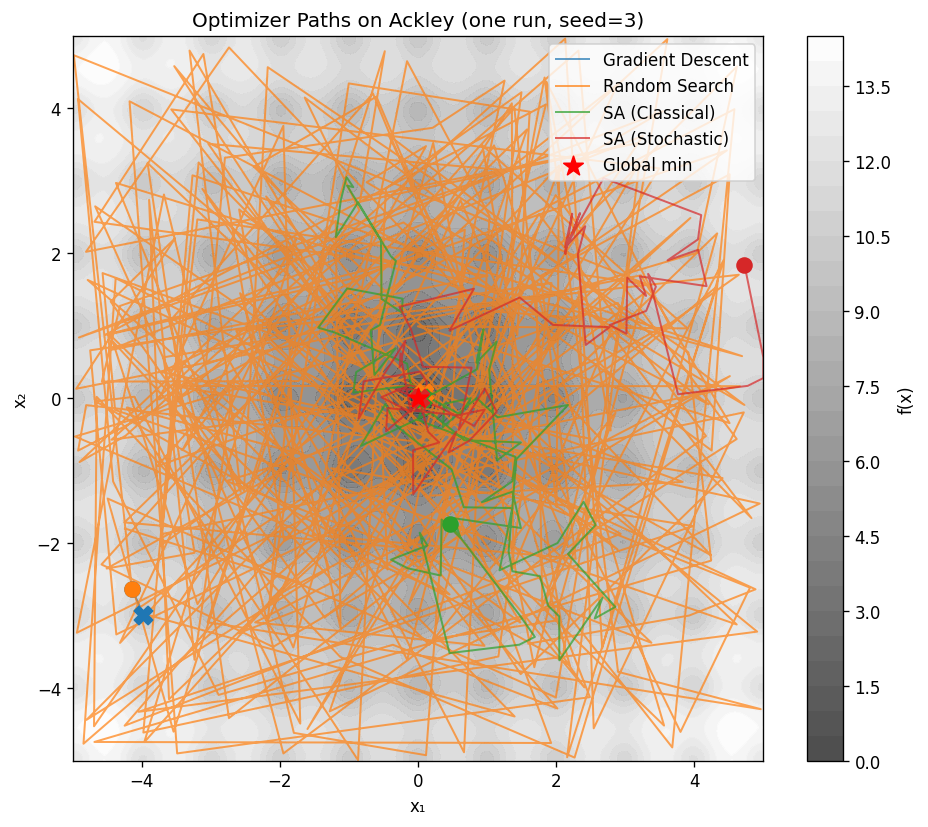

In [6]:
# One representative run (seed=3)
opts = make_optimizers(seed=3)
representative_results = {}
for name, opt in opts.items():
    r = opt.optimize(ackley, bounds=LANDSCAPES['ackley'].bounds)
    representative_results[name] = r
    print(f"{name:<22}  f* = {r.value:.5f}  at x = {r.solution}")

fig = plot_path_on_contour(
    ackley, LANDSCAPES['ackley'].bounds,
    representative_results,
    title='Optimizer Paths on Ackley (one run, seed=3)',
    known_minimum=[0, 0],
    levels=30, cmap='gray',
    max_path_points=300,
)
plt.show()

## 5  Box Plot Summary — All Landscapes

/var/folders/3x/1glgdfln2yq8vrrfnclf6n_w0000gn/T/ipykernel_44449/3375824848.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[n.replace(' ', '\n') for n in optimizer_names], patch_artist=True)
/var/folders/3x/1glgdfln2yq8vrrfnclf6n_w0000gn/T/ipykernel_44449/3375824848.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[n.replace(' ', '\n') for n in optimizer_names], patch_artist=True)
/var/folders/3x/1glgdfln2yq8vrrfnclf6n_w0000gn/T/ipykernel_44449/3375824848.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[n.replace(' ',

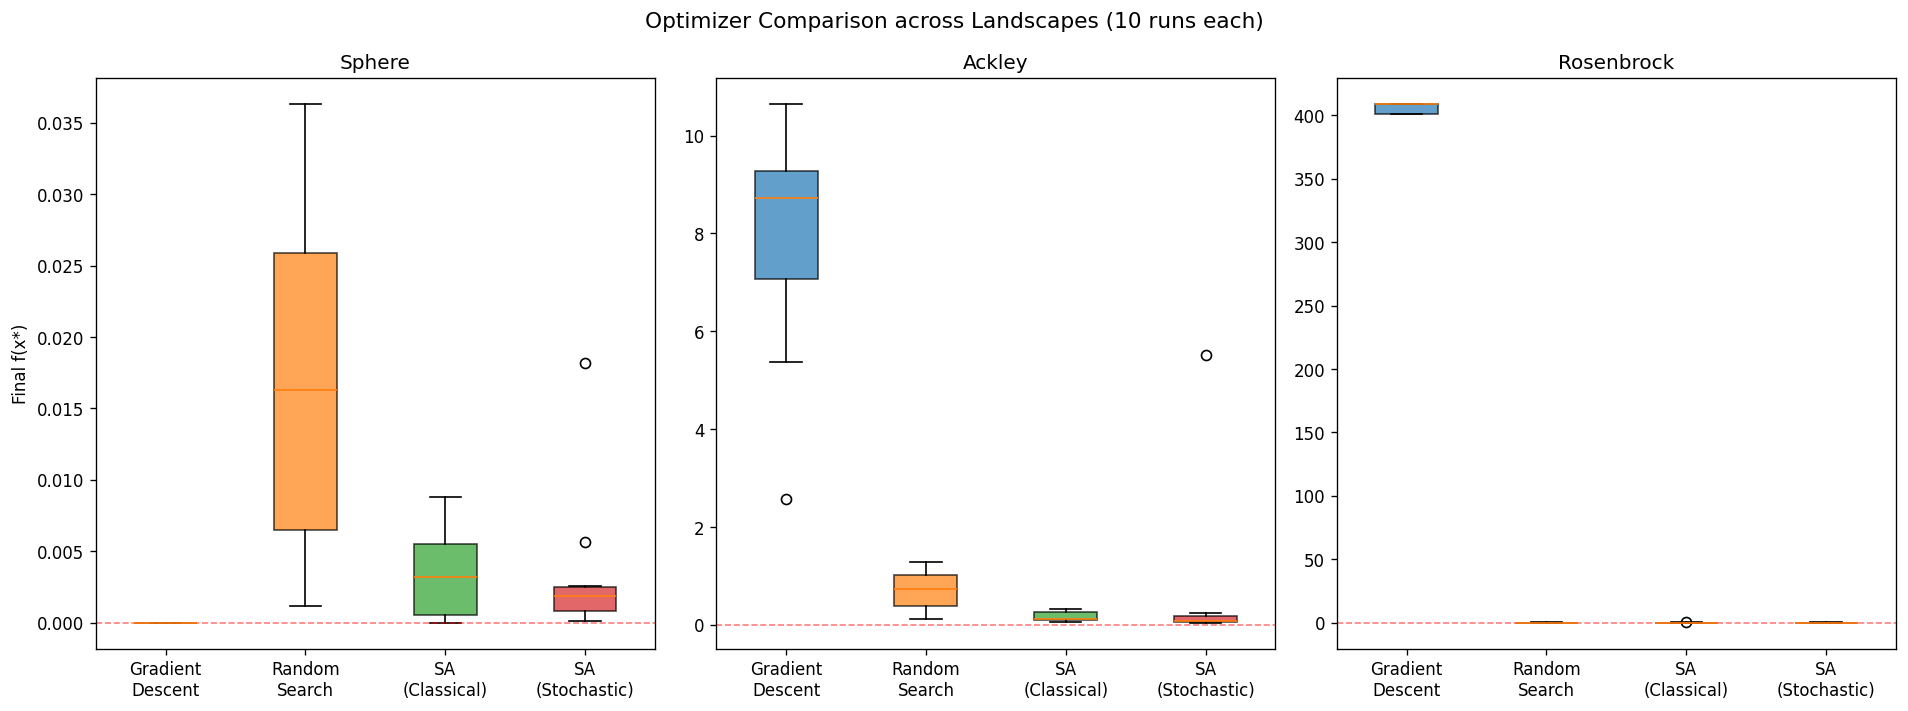

In [7]:
all_results = {
    'Sphere': sphere_results,
    'Ackley': ackley_results,
    'Rosenbrock': rosenbrock_results,
}

optimizer_names = list(sphere_results.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (landscape_name, res_dict) in zip(axes, all_results.items()):
    data = [[v for v, _ in res_dict[name]] for name in optimizer_names]
    bp = ax.boxplot(data, labels=[n.replace(' ', '\n') for n in optimizer_names], patch_artist=True)
    colors = plt.cm.tab10.colors
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(landscape_name)
    ax.set_ylabel('Final f(x*)' if ax == axes[0] else '')

plt.suptitle(f'Optimizer Comparison across Landscapes ({N_RUNS} runs each)', fontsize=13)
plt.tight_layout()
plt.show()

## 6  Where GD Fails: Starting Point Sensitivity on Ackley

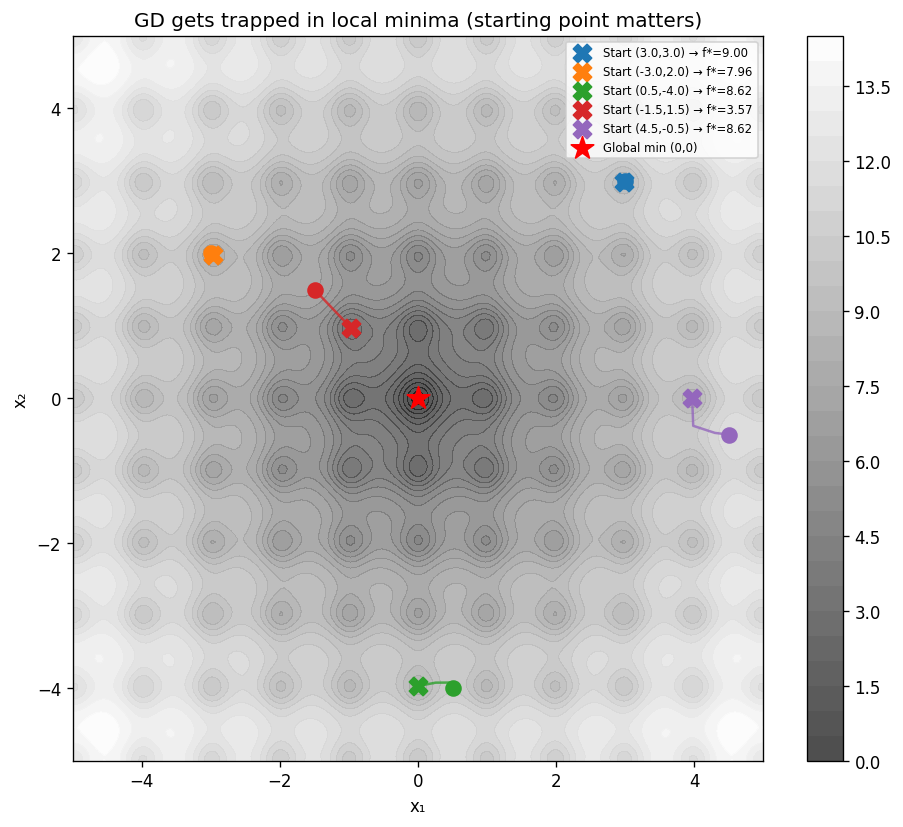

In [8]:
# Show GD converging to different local minima from different starting points
from simulated_annealing.utils.visualization import _make_grid

start_points = [
    np.array([3.0, 3.0]),
    np.array([-3.0, 2.0]),
    np.array([0.5, -4.0]),
    np.array([-1.5, 1.5]),
    np.array([4.5, -0.5]),
]

X, Y, Z = _make_grid(ackley, [(-5,5),(-5,5)], 200)
fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.contourf(X, Y, Z, levels=30, cmap='gray', alpha=0.7)
fig.colorbar(cf, ax=ax)

colors = plt.cm.tab10.colors
for i, x0 in enumerate(start_points):
    gd = GradientDescent(lr=0.02, n_iters=500, seed=0)
    r = gd.optimize(ackley, bounds=[(-5,5),(-5,5)], x0=x0)
    path = r.path[::5] + [r.path[-1]]
    xs = [p[0] for p in path]
    ys = [p[1] for p in path]
    ax.plot(xs, ys, '-', color=colors[i], linewidth=1.5, alpha=0.8)
    ax.scatter(x0[0], x0[1], color=colors[i], s=80, marker='o', zorder=5)
    ax.scatter(r.solution[0], r.solution[1], color=colors[i], s=120, marker='X', zorder=6,
               label=f'Start ({x0[0]:.1f},{x0[1]:.1f}) → f*={r.value:.2f}')

ax.scatter(0, 0, color='red', s=200, marker='*', zorder=7, label='Global min (0,0)')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('GD gets trapped in local minima (starting point matters)')
ax.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.show()

## Summary

| Landscape | Winner | Why |
|---|---|---|
| Sphere | GD | Convex; gradient always points to global min |
| Ackley | SA/SSA | GD gets trapped; SA escapes via probabilistic acceptance |
| Rosenbrock | GD (with momentum) | Narrow valley suits gradient following once inside |

**Key takeaway:** No single optimizer wins on all landscapes.  SA is especially valuable when:
- The objective is **multimodal** (many local minima)
- **No gradient** is available (black-box, noisy, or discrete objective)
- Getting **stuck in a local minimum** has a high cost

➡ **Next:** [05_constraints.ipynb](05_constraints.ipynb) — using SA for constrained optimization.